# Lab 04: Data Cleaning 

Objective: Understand how data cleaning choices alter downstream results and findings. In this lab, you will simulate three different approaches to handling dirty data and analyze how each method tells a different story.

For each question, discuss it with your partner before writing your answer. Be sure to justify your reasoning and reference the data when appropriate.

Your Name(s): Diyan & Mekayl


**Scenario**: The University launched a 3-month "Campus Wellness Pilot," giving smartwatches to 500 students and staff to see if the program increased physical activity over time. You have been handed the dataset (`wellness_tracker.csv`).

This dataset contains daily step counts for each participant over the 3-month period. It has the following columns:
- `user_id`: The unique identifier for each participant.
- `month`: The month of the recorded step count.
- `day`: The day of the recorded step count.
- `steps`: The number of steps recorded by the smartwatch on that day.

---

## Question 1
Do you think the Campus Wellness Pilot will increase physical activity among participants over the 3-month period? Explain your reasoning.

It will increase physical activiity as the "smartwatch" and program itself will motivate students to excercise more.

___

However, smartwatch data is noisy:
- Some days logged exactly 0 steps (maybe the user took the watch off or left it charging).
- Some days logged NaN (maybe the Bluetooth app failed to sync to the servers).

In [1]:
# let's take a look at the data

# first we need to import the necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
pd.set_option('display.max_rows', 50)

# load the dataset
df = pd.read_csv('wellness_tracker.csv')
df

,user_id,month,day,steps
0,1,1,1,3651.0
1,1,1,2,0.0
2,1,1,3,4911.0
3,1,1,4,NaN
4,1,1,5,4099.0
...,...,...,...,...
44995,500,3,26,4621.0
44996,500,3,27,0.0
44997,500,3,28,0.0
44998,500,3,29,5342.0


___

## Question 2
What is the unit of observation in this dataset?


The unit of observation is user per day. As each row shows the number of steps taken by a user on a specific day.
___

**The Three Cleaning Options**

You must evaluate three different approaches to handling this missing data:
- **Plan A**: Delete any row with a NaN or a 0. 
- **Plan B**: Convert all NaN to 0 steps. 
- **Plan C**: Replace all NaN and 0 values with the overall dataset average. 

___

## Question 3

Before looking at the effects of these plans for cleaning the data, pick which of the three plans you think is the best approach and justify your choice.

I'd choose Plan A because it doesn't make up any numbers. A step count of 0 most likely means the device didn't sync, not that the person truly took no steps, so those rows don't tell us about real activity. Plan B treats missing data as zero steps, which would make people look much less active than they are. Plan C fills in the gaps with the average which hides real differences between people. The downside of Plan A is that it shrinks the dataset, but I'd rather have less data that's real than more data that's made up or assumed.

Average steps by month (Plan A, B, and C):


plan,A,B,C
month,,,
1,6044.0,5238.0,6066.0
2,6195.0,4623.0,6197.0
3,6438.0,3994.0,6349.0



Records retained by month:


plan,A,B,C
month,,,
1,12999,15000,15000
2,11194,15000,15000
3,9307,15000,15000


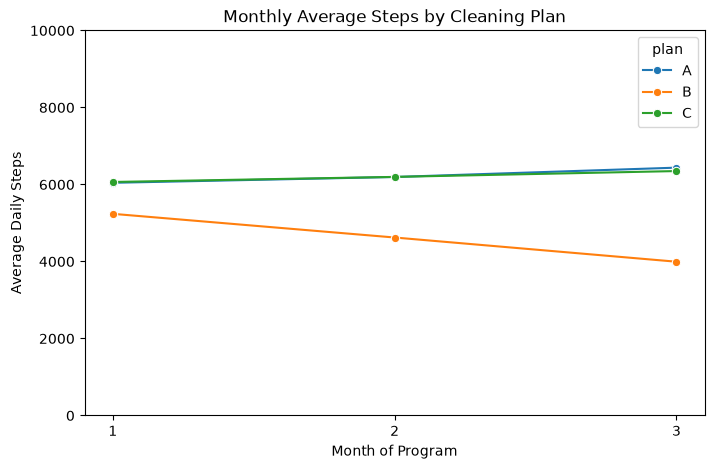

In [3]:
# run this cell!

def clean_data(raw_df, strategy):
    """
    Applies a specific cleaning strategy and visualizes the results.
    Accepts strategy 'A', 'B', or 'C'.
    """
    df = raw_df.copy()
    
    if strategy == "A":
        # The Purge: Drop NaNs and zeros
        df = df.dropna(subset=['steps'])
        df = df[df['steps'] > 0]
        title = "Strategy A: Drop Missing & Zeros"
        
    elif strategy == "B":
        # The Pessimist: Assume NaNs are 0s
        df['steps'] = df['steps'].fillna(0)
        title = "Strategy B: Convert Missing to Zeros"
        
    elif strategy == "C":
        # The Imputer: Replace NaNs and 0s with the overall mean
        overall_mean = df[df['steps'] > 0]['steps'].mean()
        df['steps'] = df['steps'].replace(0, np.nan)
        df['steps'] = df['steps'].fillna(overall_mean)
        title = "Strategy C: Impute with Global Mean"
        
    else:
        raise ValueError("Strategy must be 'A', 'B', or 'C'")
    
    return df

def compute_metrics(df):
    # Calculate metrics
    month_1_avg = df[df['month'] == 1]['steps'].mean()
    month_1_records = len(df[df['month'] == 1])

    month_2_avg = df[df['month'] == 2]['steps'].mean()
    month_2_records = len(df[df['month'] == 2])

    month_3_avg = df[df['month'] == 3]['steps'].mean()
    month_3_records = len(df[df['month'] == 3])
    
    # Print summary
    title = f"Cleaning Plan {cleaning_plan}"
    print(f"--- {title} ---")
    print(f"Month 1 Average Steps: {month_1_avg:.0f}")
    print(f"Month 2 Average Steps: {month_2_avg:.0f}")
    print(f"Month 3 Average Steps: {month_3_avg:.0f}")
    print(f"Total valid records remaining in Month 1: {month_1_records}")
    print(f"Total valid records remaining in Month 2: {month_2_records}")
    print(f"Total valid records remaining in Month 3: {month_3_records}")
    print("-" * 30 + "\n")
    
    # Visualize
    plt.figure(figsize=(8, 5))
    sns.barplot(data=df, x='month', y='steps', errorbar=None, hue='month', legend=False)
    plt.title(f"Average Steps by Month\n({title})")
    plt.ylabel("Average Daily Steps")
    plt.xlabel("Month of Program")
    plt.ylim(0, 10000)
    plt.show()

comparison_rows = []
for strategy in ["A", "B", "C"]:
    strategy_df = clean_data(df, strategy)
    monthly_summary = strategy_df.groupby("month")["steps"].agg(
        average_steps="mean", records="size"
    ).reset_index()
    monthly_summary["plan"] = strategy
    comparison_rows.append(monthly_summary)

comparison_df = pd.concat(comparison_rows, ignore_index=True)
print("Average steps by month (Plan A, B, and C):")
display(comparison_df.pivot(index="month", columns="plan", values="average_steps").round(0))
print("\nRecords retained by month:")
display(comparison_df.pivot(index="month", columns="plan", values="records"))

plt.figure(figsize=(8, 5))
sns.lineplot(data=comparison_df, x="month", y="average_steps", hue="plan", marker="o")
plt.title("Monthly Average Steps by Cleaning Plan")
plt.ylabel("Average Daily Steps")
plt.xlabel("Month of Program")
plt.xticks([1, 2, 3])
plt.ylim(0, 10000)
plt.show()

Input your preferred data cleaning strategy below.

In [10]:
cleaning_plan = "C" # Choose between "A", "B", or "C" based on your preferred data cleaning strategy

Now, let's clean the data!

In [11]:
cleaned_df = clean_data(df, cleaning_plan)
cleaned_df.head(10)

,user_id,month,day,steps
0,1,1,1,3651.000000
1,1,1,2,6203.958985
2,1,1,3,4911.000000
3,1,1,4,6203.958985
4,1,1,5,4099.000000
5,1,1,6,2751.000000
6,1,1,7,2807.000000
7,1,1,8,719.000000
8,1,1,9,4282.000000
9,1,1,10,2904.000000


Let's compute statistics for each month and visualize them using a histogram.

--- Cleaning Plan C ---
Month 1 Average Steps: 6066
Month 2 Average Steps: 6197
Month 3 Average Steps: 6349
Total valid records remaining in Month 1: 15000
Total valid records remaining in Month 2: 15000
Total valid records remaining in Month 3: 15000
------------------------------



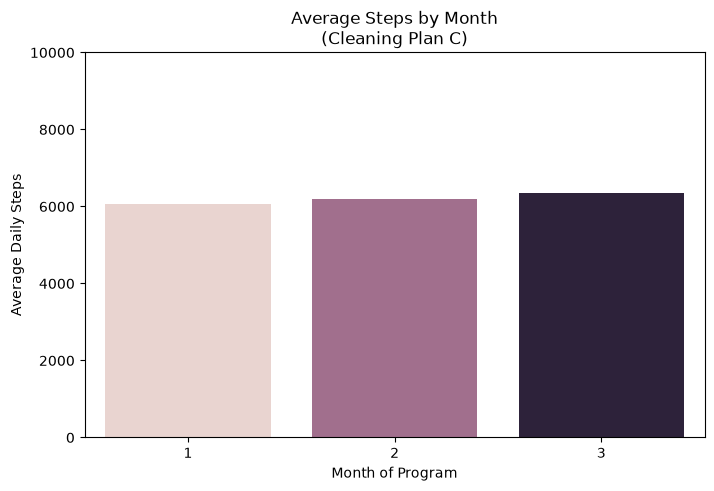

In [13]:
compute_metrics(cleaned_df)

___

## Question 4

Based on the computed metrics and visualizations, do you think the Campus Wellness Pilot increase physical activity over the 3-month period? Explain your reasoning. Is there any information in the computed metrics that might suggest the visualization is misleading?

Plan A shows a small increase. Average daily steps go up each month, from 6,044 to 6,195 to 6,438, which is about 6.5% over three months.

But the chart could be misleading. The number of records left drops each month, from 12,999 to 11,194 to 9,307, and the bars don't show that. If the people who stopped syncing their device were the less active ones, the month 3 average is only made up of the most active people, and that alone could increase it. So the pilot may have helped a little, but I wouldn't say it properly increased activity.

___

## Question 5

Does this finding align with your expectations from Question 1? Why or why not?

Yes, this mostly matches what I expected. I thought the smartwatch and the program would motivate students to exercise more, and Plan A shows steps going up each month. But I'm less confident than before. Since the records drop each month, part of the increase could come from less active students leaving the data, so I can't say my expectation is completely right.

## Question 6

Now, go back and try the other two data cleaning plans. You can do this by changing the value of the `cleaning_plan` variable and re-running cells where you create the cleaned dataset and compute the statistics. 

Using the results from the other two cleaning plans, do you think your choice of cleaning plan affected the results? Explain your reasoning. Knowning these results, would you make the same choice again? Why or why not?


Yes, the cleaning plan changed the results a lot. Plans A and C both showed steps going up, but Plan B showed steps going down. Plan B turns every missing day into 0 steps, and since more days go missing each month, the average gets pulled down. That drop comes from the missing data, not from students walking less. Plan C keeps all the records, but it fills the gaps with the overall average, which hides real differences between students.

Using this, I would make the same choice again and use Plan A. It doesn't make up any numbers and doesn't treat missing data as zero steps. The con is that it reduces the dataset each month, so I'd be careful about trusting the upward trend too much.

## Question 7
Suppose your analysis will be used to inform the college's decision to expand the program. The administration wants a simple "Yes" or "No" on whether to spend $500,000 expanding this program next year. Based on your understanding of the data's flaws, what do you tell them, and which chart do you show to justify it?


I would tell them no. The data isn't reliable enough to justify $500,000. Steps went up a little under Plan A, but more data goes missing each month, so we can't tell if students became more active or if the less active ones just stopped syncing their devices. The result also changes depending on how we clean the data, and we have no group of students without smartwatches to compare against.

I would show the line chart and bar chart comparing all three plans, because it shows the answer changes depending on how we handle the missing data. I'd recommend fixing the syncing problem and running a longer program before deciding.